# Teachable Machine, dataset propio y Gradio

En esta actividad vas a crear un clasificador de imágenes propio. La secuencia completa tiene cuatro momentos: diseñar el problema, recolectar imágenes, entrenar en Teachable Machine y probar el modelo desde una interfaz web con Gradio.

## Objetivos de aprendizaje

Al finalizar la actividad, vas a poder:

- definir clases visuales para un problema de clasificación;
- construir un dataset ordenado por carpetas;
- aplicar criterios de curaduría para reducir sesgos;
- entrenar y probar un modelo en Teachable Machine;
- exportar el modelo y usarlo desde Python con Gradio.

## 1. Diseñar el problema de clasificación

Antes de descargar imágenes, definí el problema. Un buen clasificador necesita clases claras y ejemplos representativos.

Completá estas decisiones:

- clases del modelo: entre 2 y 4 categorías;
- rasgos visuales esperados: qué debería mirar el modelo;
- posibles confusiones: qué clases podrían parecerse;
- contexto de uso: con qué tipo de imágenes se probará después.

**Consigna de trabajo:** escribí una hipótesis breve. Por ejemplo: “El modelo debería distinguir hojas de roble y hojas de eucalipto por la forma del borde y la nervadura, no por el fondo de la foto”.

## 💭 Hipótesis: "El modelo debería distinguir apio de brócolis por la forma del tallo, hojas y flor, no por el fondo de la foto"


## 2. Recolectar imágenes

### Método rápido: extensiones de navegador

Para trabajar en clase, las extensiones permiten armar carpetas en pocos minutos desde búsquedas de imágenes.

Opciones posibles:

- **Download All Images / ZipImageDownloader**: permite descargar muchas imágenes visibles en una pestaña.
- **Image Downloader**: muestra una grilla de imágenes y permite seleccionar cuáles descargar.

### Método in situ: webcam de Teachable Machine

Si el problema se puede resolver con objetos del aula, gestos o expresiones, la webcam de Teachable Machine permite capturar muchas imágenes rápidamente con variaciones de posición, luz y fondo.

## 3. Organizar carpetas

Teachable Machine puede cargar imágenes por clase si están ordenadas en carpetas.

Usá esta estructura:

```text
Dataset/
  clase_1/
    imagen_001.jpg
    imagen_002.jpg
  clase_2/
    imagen_001.jpg
    imagen_002.jpg
```

Los nombres de las carpetas deben representar las clases. Por ejemplo: `Dataset/gato` y `Dataset/perro`.

**Consigna de trabajo:** cada grupo debería reunir entre 50 y 100 imágenes por clase para una primera prueba.

## 4. Curar el dataset

El modelo aprende a partir de los ejemplos que recibe. Si los ejemplos están sesgados, el modelo puede aprender atajos incorrectos.

Revisá estos criterios:

- **Balance de clases**: cada clase debería tener una cantidad similar de imágenes.
- **Variedad**: incluí distintos fondos, ángulos, tamaños e iluminaciones.
- **Ruido**: eliminá imágenes borrosas, duplicadas o irrelevantes.
- **Sesgo de fondo**: evitá que una clase aparezca siempre con el mismo fondo.

Ejemplo: si todas las fotos de gatos están en un sillón rojo y todas las de perros están en pasto verde, el modelo puede aprender a distinguir fondos en lugar de animales.

**Consigna de lectura:** revisá 10 imágenes de cada clase. Marcá cuáles podrían introducir sesgo y explicá por qué.

## ✍ Las imágenes que podrían introducir sesgo son las que aparecen con fondo blanco porque el modelo aprende a reconocer el entorno.

## 5. Entrenar en Teachable Machine

Pasos sugeridos:

1. Entrá a Teachable Machine.
2. Creá un proyecto de imagen.
3. Cargá las carpetas de cada clase.
4. Entrená el modelo.
5. Probalo con webcam o con imágenes nuevas.

Hiperparámetros básicos:

- **Epochs**: cantidad de veces que el modelo recorre los ejemplos.
- **Batch Size**: cantidad de imágenes procesadas en cada paso.
- **Learning Rate**: tamaño de los ajustes durante el aprendizaje. Si no se modifica, conviene dejar el valor por defecto.

## 6. Hackear el modelo

Después de entrenar, intentá encontrar casos donde el modelo falle. Este paso es importante porque permite entender qué aprendió realmente.

Pruebas posibles:

- una imagen con fondo distinto;
- una imagen con poca luz;
- una imagen de un objeto parcialmente tapado;
- una imagen parecida a dos clases;
- una imagen que no pertenezca a ninguna clase.

**Consigna de análisis:** cuando el modelo falle, formulá una hipótesis. ¿Faltó variedad? ¿Había sesgo de fondo? ¿Las clases eran demasiado parecidas? ¿El dataset estaba desbalanceado?

## 💭 Se puede pensar que el modelo falla al recibir como entrada una imagen distinta a las que recibió antes porque tiene muy pocas muestras de cada clase, causando ello un sobreajuste.
En este caso, se ingresó la imagen de unas zanahorias y el modelo predijo con un 100% de probabilidad que pertenece a la clase apio.
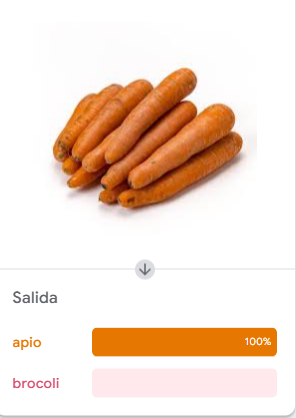

Al observar la precisión por época, podemos notar el sobreajusta ya que en la época 1, la precisión es del 100 %
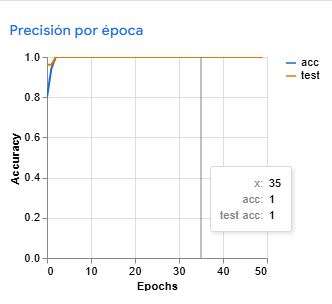

## 7. Exportar el modelo

Para usar el modelo fuera de Teachable Machine:

1. Hacé clic en **Export Model**.
2. Elegí **TensorFlow / Keras**.
3. Descargá el archivo `.zip`.
4. Descomprimilo.
5. Ubicá estos archivos en la carpeta de trabajo:
   - `keras_model.h5`;
   - `labels.txt`.

## 8. Instalar dependencias para Gradio

Gradio permite crear una interfaz web simple para probar el modelo con imágenes nuevas.

In [ ]:
import tensorflow_datasets as tfds

In [ ]:
!pip install -q gradio tensorflow pillow numpy

In [ ]:
import tensorflow as tf

In [ ]:
print(tf.__version__)

2.21.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 9. Cargar modelo y etiquetas

Esta celda espera que `keras_model.h5` y `labels.txt` estén en la misma carpeta del notebook.

In [ ]:
# 1. Instalamos la librería de compatibilidad histórica (por si acaso)
!pip install tf-keras


In [10]:

# 2. Importamos Keras usando el motor clásico
import tf_keras as keras
import numpy as np

# 3. Cargamos el modelo (aquí ya NO necesitas trucos ni parches raros)
ruta_modelo = "/content/drive/MyDrive/Colab Notebooks/Teacheable_Machine/keras_model.h5" # Ajusta tu ruta
modelo_teachable = keras.models.load_model(ruta_modelo, compile=False)

print("¡Modelo cargado de forma nativa y 100% compatible!")

¡Modelo cargado de forma nativa y 100% compatible!


In [9]:
from pathlib import Path

import gradio as gr
import numpy as np
from PIL import Image, ImageOps

ruta_etiquetas = Path("/content/drive/MyDrive/Colab Notebooks/Teacheable_Machine/labels.txt") # Convert to Path object

nombres_clases = []

with ruta_etiquetas.open("r", encoding="utf-8") as archivo_etiquetas:

  lineas_etiquetas = archivo_etiquetas.readlines()
  for linea in lineas_etiquetas:
    nombre_clase = linea.strip().split(" ", 1)[-1]
    nombres_clases.append(nombre_clase)

print("Clases cargadas:", nombres_clases)

Clases cargadas: ['apio', 'brocoli']


## 10. Definir la función de predicción

Teachable Machine espera imágenes de 224 x 224 píxeles y valores normalizados al rango `[-1, 1]`. Por eso adaptamos cada imagen antes de enviarla al modelo.

In [11]:
def preprocesar_imagen_para_teachable(imagen_numpy):
    imagen_pil = Image.fromarray(imagen_numpy.astype("uint8"), "RGB")

    tamano_esperado = (224, 224)
    imagen_redimensionada = ImageOps.fit(
        imagen_pil,
        tamano_esperado,
        Image.Resampling.LANCZOS,
    )

    arreglo_imagen = np.asarray(imagen_redimensionada)
    arreglo_imagen = arreglo_imagen.astype(np.float32)
    arreglo_imagen = (arreglo_imagen / 127.5) - 1

    lote_imagenes = np.expand_dims(arreglo_imagen, axis=0)

    return lote_imagenes


def predecir_imagen(imagen_entrada):
    if imagen_entrada is None:
        return {"Sin imagen": 1.0}

    lote_imagenes = preprocesar_imagen_para_teachable(imagen_entrada)
    prediccion = modelo_teachable.predict(lote_imagenes, verbose=0)

    probabilidades = {}

    for indice, nombre_clase in enumerate(nombres_clases):
        puntaje = float(prediccion[0][indice])
        probabilidades[nombre_clase] = puntaje

    return probabilidades

**Consigna de lectura:** identificá dónde se redimensiona la imagen y dónde se normaliza. ¿Por qué esos pasos deben coincidir con el entrenamiento original?

## 11. Crear la interfaz con Gradio

La interfaz permite subir una imagen o usar la cámara, según el entorno donde ejecutes el notebook. El parámetro `share=True` genera un enlace temporal para probar el modelo desde otros dispositivos.

In [12]:
demo = gr.Interface(
    fn=predecir_imagen,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=3),
    title="Clasificador de imágenes con Teachable Machine",
    description="Subí una imagen para probar el modelo entrenado en clase.",
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://afe17c73b5ca757f17.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Cierre y discusión

Para cerrar la actividad, compará el resultado del modelo con las decisiones tomadas durante la recolección de imágenes.

Preguntas para discutir:

- ¿Qué clases funcionaron mejor?
- ¿Qué errores se repitieron?
- ¿Qué imágenes faltaron en el dataset original?
- ¿El modelo aprendió el objeto principal o algún rasgo del fondo?
- ¿Qué cambiarías si tuvieras que entrenarlo otra vez?

## 🎯 El error que se detectó fue que el modelo fue entrenado con pocas muestras de cada clase lo que llevó a un sobreajuste ya qu ecada clase alcanzó una precisión del 100 %. En el dataset original faltaron más imágenes con diferentes ángulos y fondos para evitar que aprenda el fondo y pueda aprender rasgos del objeto. Para entrenarlo otra vez aumentaría las muestras considerando disfintos ángulos y fondos.